In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = { 
'RPM': [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500], 
'Fuel_Consum': [5.2, 5.8, 6.5, 7.5, 9.0, 11.2, 14.5, 18.2, 23.0, 29.5] 
}
df = pd.DataFrame(data)
print("Engine Speed and Fuel Consumption data (non-linear Patterns)")
print(df)

Engine Speed and Fuel Consumption data (non-linear Patterns)
    RPM  Fuel_Consum
0  1000          5.2
1  1500          5.8
2  2000          6.5
3  2500          7.5
4  3000          9.0
5  3500         11.2
6  4000         14.5
7  4500         18.2
8  5000         23.0
9  5500         29.5


In [3]:
X = df[['RPM']]
Y = df['Fuel_Consum']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.25,
    random_state = 42
)

In [4]:
degree = 3
poly = PolynomialFeatures (degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [5]:
model = LinearRegression()
model.fit(X_train_poly, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
coefficient= model.coef_
intercept = model.intercept_
print(coefficient)
print(f"Polynomial Regression Equation (degree {degree}):")
print(f"Height = {intercept:.2f}")
for i, ef in enumerate(coefficient, 1):
    print(f"     + {ef:.10f} x RPM^{i}")
print()

[ 1.08578622e-03 -3.90950147e-07  1.86415938e-10]
Polynomial Regression Equation (degree 3):
Height = 4.33
     + 0.0010857862 x RPM^1
     + -0.0000003910 x RPM^2
     + 0.0000000002 x RPM^3



In [7]:
Y_pred = model.predict(X_test_poly)
print(f"MAE: {mean_absolute_error(Y_test, Y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred))}")
print(f"R2 Score: {r2_score(Y_test, Y_pred)}")

MAE: 0.17176096387153775
RMSE: 0.1919279649846173
R2 Score: 0.9992858713301563


D:\Anaconda-navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


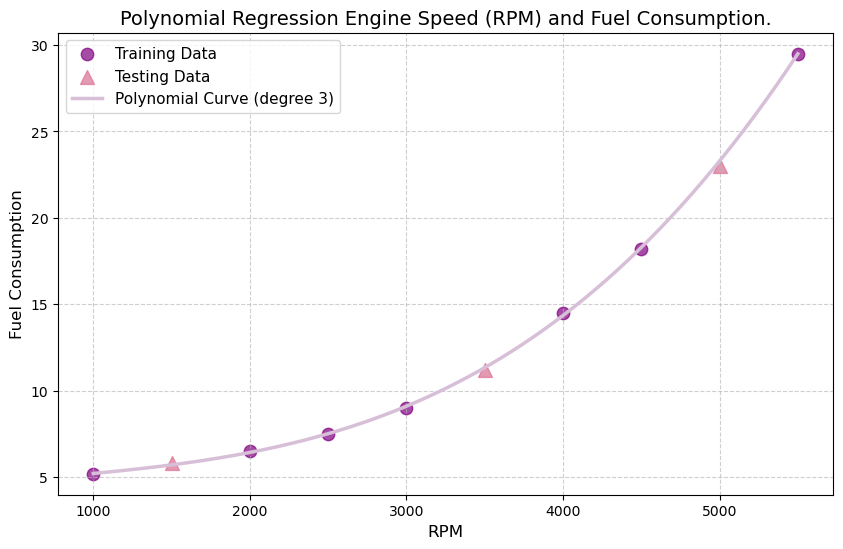

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(X_train, Y_train, color='purple', label='Training Data', s=80, alpha=0.7)
plt.scatter(X_test, Y_test, color='palevioletred', label='Testing Data', s=100, marker='^', alpha=0.7)

X_curve = np.linspace(1000, 5500, 200).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = model.predict(X_curve_poly)

plt.plot(X_curve, y_curve, color='thistle', linewidth=2.5, label=f'Polynomial Curve (degree {degree})')
plt.xlabel('RPM', fontsize=12)
plt.ylabel('Fuel Consumption', fontsize=12)
plt.title('Polynomial Regression Engine Speed (RPM) and Fuel Consumption.', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

For this model straight line is poor fit because fuel consumption increases at the accelerating rate as RPM increases. Linear regression assumes constant growth but here the data shows exponential like growth. A degree-3 polynomial captures this curvature, reducing residual error and improving model accuracy.

In [276]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

data = {
    'Attendance': [95, 70, 45, 88, 60, 92, 50, 80, 75, 98],
    'Midterm': [48, 30, 15, 45, 20, 49, 10, 35, 32, 50],
    'Final_Grade': [90, 65, 30, 85, 45, 92, 25, 75, 70, 98]
}

df = pd.DataFrame(data)
print(df)

   Attendance  Midterm  Final_Grade
0          95       48           90
1          70       30           65
2          45       15           30
3          88       45           85
4          60       20           45
5          92       49           92
6          50       10           25
7          80       35           75
8          75       32           70
9          98       50           98


In [277]:
X = df[['Attendance', 'Midterm']]
y = df['Final_Grade']

In [278]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f"KNN R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Average Error (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")

KNN R2 Score: 0.9639
Average Error (MAE): $2.00


In [279]:
knn1 = KNeighborsRegressor(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
y_pred1 = knn1.predict(X_test_scaled)

print(f"KNN (K=1) R2 Score: {r2_score(y_test, y_pred1):.4f}")
print(f"Average Error (MAE): ${mean_absolute_error(y_test, y_pred1):.2f}")

KNN (K=1) R2 Score: 0.6874
Average Error (MAE): $5.67


In [280]:
knn9 = KNeighborsRegressor(n_neighbors=9)
knn9.fit(X_train_scaled, y_train)
y_pred9 = knn9.predict(X_test_scaled)

print(f"KNN (K=9) R2 Score: {r2_score(y_test, y_pred9):.4f}")
print(f"Average Error (MAE): ${mean_absolute_error(y_test, y_pred9):.2f}")

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 9, n_samples_fit = 7, n_samples = 3

In [281]:
knn7 = KNeighborsRegressor(n_neighbors=7)
knn7.fit(X_train_scaled, y_train)
y_pred7 = knn7.predict(X_test_scaled)

print(f"KNN (K=7) R2 Score: {r2_score(y_test, y_pred7):.4f}")
print(f"Average Error (MAE): ${mean_absolute_error(y_test, y_pred7):.2f}")

KNN (K=7) R2 Score: -0.9895
Average Error (MAE): $11.67


D:\Anaconda-navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


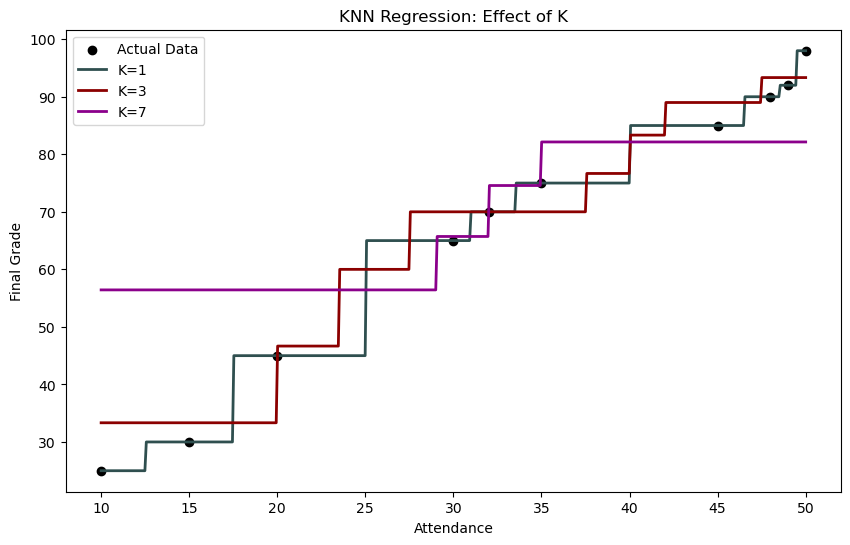

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# 1. Use ONLY ONE feature for visualization
X_vis = df[['Midterm']]   # single feature
y_vis = df['Final_Grade']

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# 3. Create smooth range
X_range = np.linspace(X_vis.min(), X_vis.max(), 500).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_vis, y_vis, color='black', label='Actual Data')

for k, color in zip([1, 3, 7], ['darkslategray', 'darkred', 'darkmagenta']):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_scaled, y_vis)
    y_pred = knn.predict(X_range_scaled)
    plt.plot(X_range, y_pred, color=color, label=f'K={k}', linewidth=2)

plt.title('KNN Regression: Effect of K')
plt.xlabel('Attendance')
plt.ylabel('Final Grade')
plt.legend()
plt.show()

K=9 is giving error because 70% data was given for the training not the complete data.

K=1 gives perfect training accuracy because each data point is its own nearest neighbor, resulting in zero training error. However, it fails on test data due to overfitting and high variance. Larger K values reduce variance but may introduce bias. A moderate K (such as 3) provides the best balance between bias and variance, resulting in better generalization performance.

In [267]:
#Built in train_test_split
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = {
    'Attendance': [95, 70, 45, 88, 60, 92, 50, 80, 75, 98],
    'Midterm': [48, 30, 15, 45, 20, 49, 10, 35, 32, 50],
    'Final_Grade': [90, 65, 30, 85, 45, 92, 25, 75, 70, 98]
}

df = pd.DataFrame(data)

X = df[['Attendance', 'Midterm']]
y = df['Final_Grade']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Sklearn Train indices:", list(X_train2.index))
print("Sklearn Test  indices:", list(X_test2.index))
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MSE       : {mse:.4f}")
print(f"R² Score  : {r2:.4f}")
print(f"RMSE      : {rmse:.4f}")

Sklearn Train indices: [5, 0, 7, 2, 9, 4, 3, 6]
Sklearn Test  indices: [8, 1]
MSE       : 884.4160
R² Score  : -0.0494
RMSE      : 29.7391


In [262]:
from numpy.random import RandomState
Seed=42
rng = RandomState(Seed)
shuffled_index = rng.permutation(len(df))
print("\nShuffled Indices:", shuffled_index)


Shuffled Indices: [8 1 5 0 7 2 9 4 3 6]


In [263]:
n_test  = int(0.2 * len(df))
n_train = len(df) - n_test

In [264]:
test_point  = shuffled_index[:n_test]
train_point = shuffled_index[n_test:]

print(f"Train indices: {(train_point)}")
print(f"Test  indices: {(test_point)}")

X_train_manual = X.iloc[train_point]
X_test_manual  = X.iloc[test_point]
y_train_manual = y.iloc[train_point]
y_test_manual  = y.iloc[test_point]

print("Training size:", X_train_manual.shape)
print("Testing size:", X_test_manual.shape)

Train indices: [5 0 7 2 9 4 3 6]
Test  indices: [8 1]
Training size: (8, 2)
Testing size: (2, 2)


If the sklearn shuffle split is used then the comparsion is coming as same as train_test_split because it uses the same pattern

In [266]:
model_manual = LinearRegression()
model_manual.fit(X_train_manual, y_train_manual)
y_pred_manual = model_manual.predict(X_test_manual)

mse_manual = mean_squared_error(y_test_manual, y_pred_manual)
r2_manual = r2_score(y_test_manual, y_pred_manual)
np.sqrt(mean_squared_error(y_test_manual, y_pred_manual))
print("\n=== MANUAL SPLIT RESULTS ===")
print(f"MSE       : {mse_manual:.4f}")
print(f"R² Score  : {r2_manual:.4f}")
print(f"RMSE      : {rmse_manual:.4f}")


=== MANUAL SPLIT RESULTS ===
MSE       : 26.4424
R² Score  : -3.2308
RMSE      : 5.1422


In [273]:
comparison_table = pd.DataFrame({
    "Model": ["Manual train test split", "Built-in Train test Split"],
    "MSE": [mse_manual, mse],
    "RMSE": [rmse_manual, rmse],
    "R2 Score": [r2_manual, r2]
})
print('*'*70)
print("                       --- Comparison ---")
print(comparison_table.to_string(index=False))
print('*'*70)

**********************************************************************
                       --- Comparison ---
                    Model        MSE      RMSE  R2 Score
  Manual train test split  26.442377  5.142215 -3.230780
Built-in Train test Split 884.415994 29.739132 -0.049357
**********************************************************************


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("housing.csv")  
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [29]:
df['mainroad'] = df['mainroad'].str.lower().map({'yes':1,'no':0})
df['guestroom'] = df['guestroom'].str.lower().map({'yes':1,'no':0})
df['basement'] = df['basement'].str.lower().map({'yes':1,'no':0})
df['airconditioning'] = df['airconditioning'].str.lower().map({'yes':1,'no':0})
df['prefarea'] = df['prefarea'].str.lower().map({'yes':1,'no':0})

In [30]:
print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement hotwaterheating  airconditioning  parking  prefarea  \
0         0              no                1        2         1   
1         0              no                1        3         0   
2         1              no                0        2         1   
3         1              no                1        3         1   
4         1              no                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


In [31]:
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'airconditioning', 'parking', 'prefarea']]
Y = df['price']

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [33]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)
Y_pred_poly = poly_model.predict(X_test_poly)

# Polynomial Metrics
mae_poly = mean_absolute_error(Y_test, Y_pred_poly)
rmse_poly = mean_squared_error(Y_test, Y_pred_poly)
r2_poly = r2_score(Y_test, Y_pred_poly)

print(f"Mean Square Error: {mae_poly}")
print(f"Root Mean Square Error: {rmse_poly}")
print(f"R2 square: {r2_poly}")

Mean Square Error: 1602875.5486635428
Root Mean Square Error: 7420197347729.439
R2 square: -0.723066247922592


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)  # you can experiment with K
knn_model.fit(X_train_scaled, Y_train)
Y_pred_knn = knn_model.predict(X_test_scaled)

# KNN Metrics
mae_knn = mean_absolute_error(Y_test, Y_pred_knn)
rmse_knn = mean_squared_error(Y_test, Y_pred_knn)
r2_knn = r2_score(Y_test, Y_pred_knn)

print(f"Mean Square Error: {mae_knn}")
print(f"Root Mean Square Error: {rmse_knn}")
print(f"R2 square: {r2_knn}")

Mean Square Error: 1013421.5853658536
Root Mean Square Error: 1970783983527.9023
R2 square: 0.5423583491344114


In [274]:
comparison_table = pd.DataFrame({
    "Model": ["Polynomial Regression", "KNN Regression"],
    "MAE": [mae_poly, mae_knn],
    "RMSE": [rmse_poly, rmse_knn],
    "R2 Score": [r2_poly, r2_knn]
})
print('*'*70)
print("                   --- Model Comparison ---")
print(comparison_table.to_string(index=False))
print('*'*70)

**********************************************************************
                   --- Model Comparison ---
                Model          MAE         RMSE  R2 Score
Polynomial Regression 1.602876e+06 7.420197e+12 -0.723066
       KNN Regression 1.013422e+06 1.970784e+12  0.542358
**********************************************************************
